# Q0. What does ClinVar contain, and which variants are suitable for reliable evaluation?

A full-file audit and a **proposed** conservative SNV cohort. No model, features, or splits are fitted here. All labels are explored; **this is development data, not an untouched test set**.

Run all cells with the environment described in [the README](../README.md#running-q0). Implementation: [q0.py](src/q0.py). CPU only; no Evo2 checkpoint or GPU is needed. No random sampling is used, so no random seed is required.

## 1. Input and provenance

Pinned input: GRCh38, header date **2026-09-05**. The checksum establishes file identity, not download provenance. If the VCF is absent, the existing local gzip archive is decompressed; no newer release is fetched.

In [1]:
from src import q0

variants, provenance, started = q0.load_data()

Read 500,000 records


Read 1,000,000 records


Read 1,500,000 records


Read 2,000,000 records


Read 2,500,000 records


Read 3,000,000 records


Read 3,500,000 records


Read 4,000,000 records


4,469,028 records · GRCh38 · 2026-09-05


## 2. Dataset composition

The VCF covers mapped simple alleles with precise endpoints, rather than all ClinVar submissions ([NCBI file guide](https://www.ncbi.nlm.nih.gov/clinvar/docs/ftp_primer/)). Consequences and genes can be multi-valued: each distinct annotation is counted once per record, so those totals may exceed the number of variants.

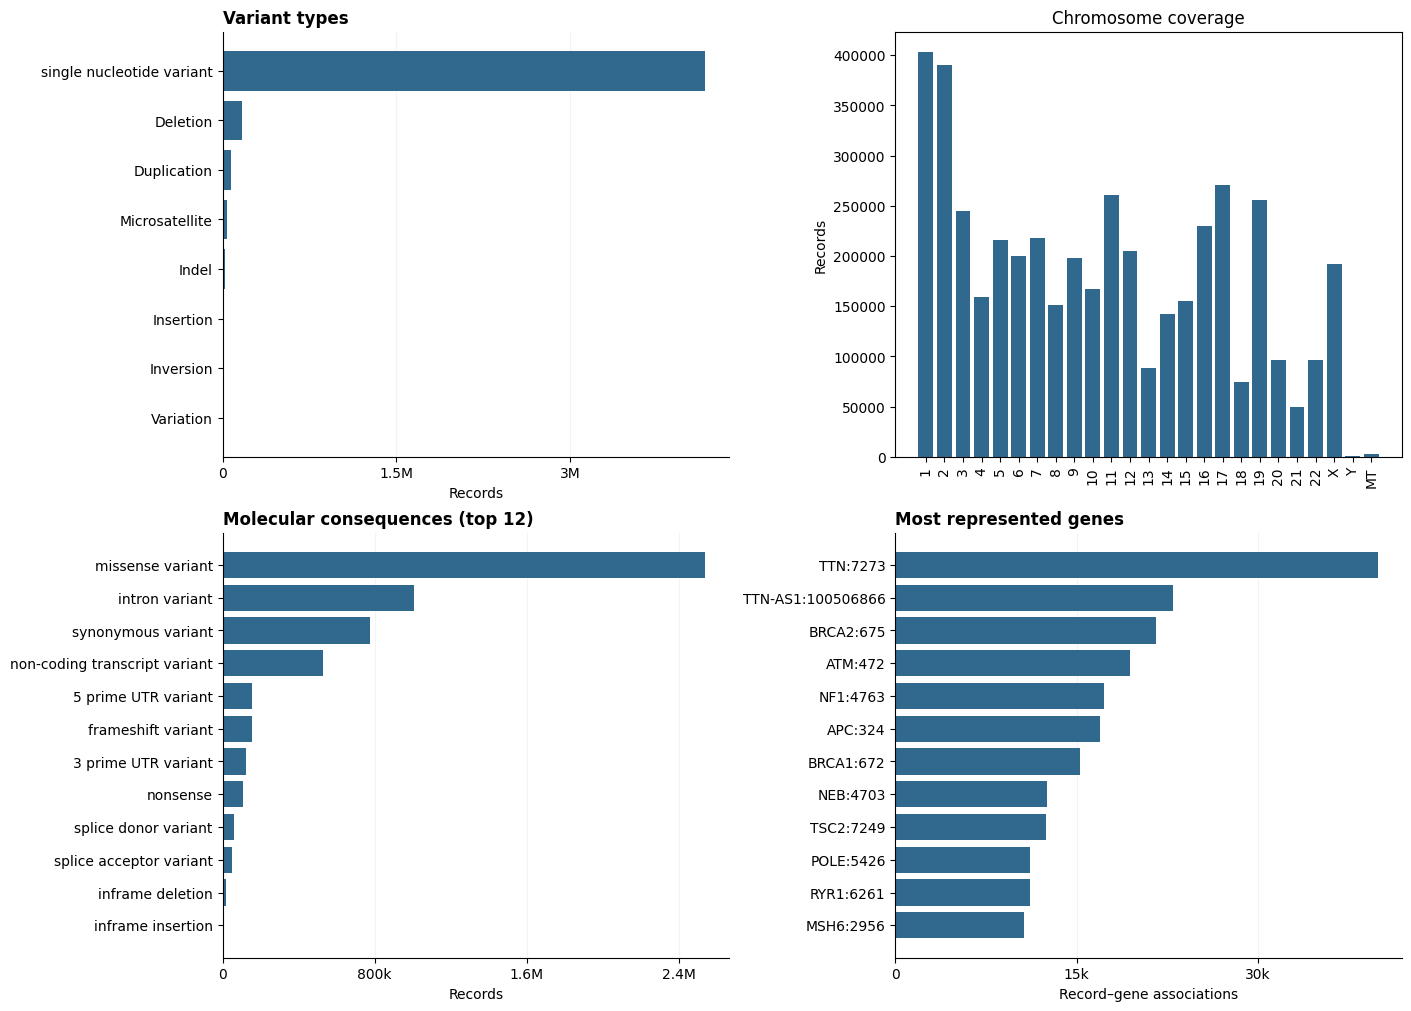

In [2]:
q0.plot_composition(variants)

## 3. Germline classifications and review

Raw classifications stay visible; only the six explicit benign/pathogenic terms below are eligible for the cohort. Somatic clinical impact and oncogenicity never substitute for germline labels. Review status is mapped to stars using [NCBI definitions](https://www.ncbi.nlm.nih.gov/clinvar/docs/review_status/); unknown spellings remain unknown. Stars describe review processes, not a guarantee of correctness.

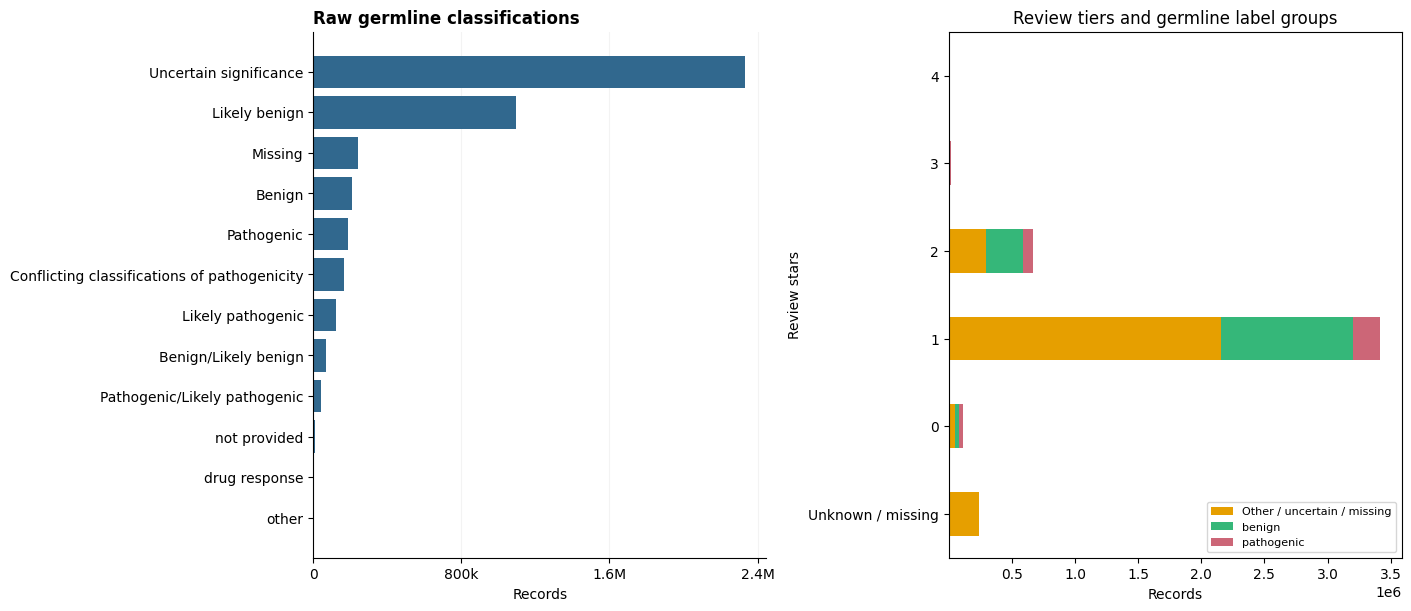

In [3]:
q0.show_classifications(variants)

## 4. Data quality

Missing annotations, duplicate rows, inconsistent duplicate annotations, and shared loci have different meanings. Raw-data issues are counted; violated parser or cohort invariants stop execution. Duplicate checks use the VCF representation and do not establish equivalence of differently represented indels.

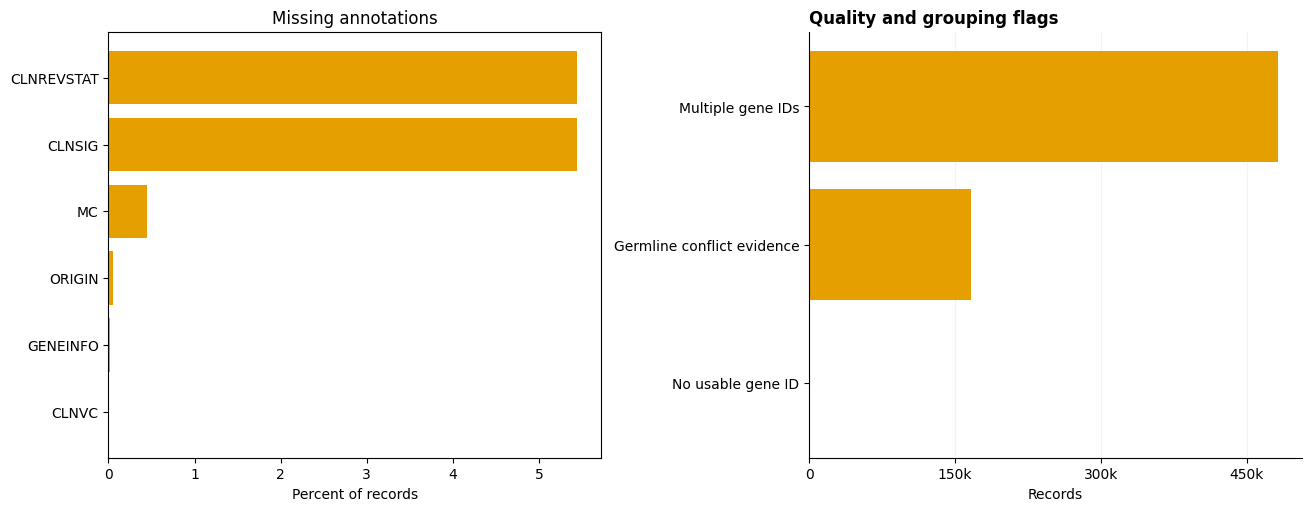

,count
CLNREVSTAT,
,243487
no_classification_for_the_single_variant,669
no_classifications_from_unflagged_records,142


In [4]:
audit = q0.show_quality(variants)

## 5. Potential leakage

Related SNVs are not independent observations. Coordinate windows use half-open intervals centered on each SNV and join transitive overlaps within a chromosome; touching windows remain separate. The plots count distinct loci, so alternate alleles are not double-counted.

These are **coordinate proxies**: no reference genome, actual sequence similarity, chromosome-end clipping, patient relationships, gene-family similarity, or pretrained-model contamination is checked. Future split construction must jointly group duplicate identifiers, loci, overlapping contexts, and genes.

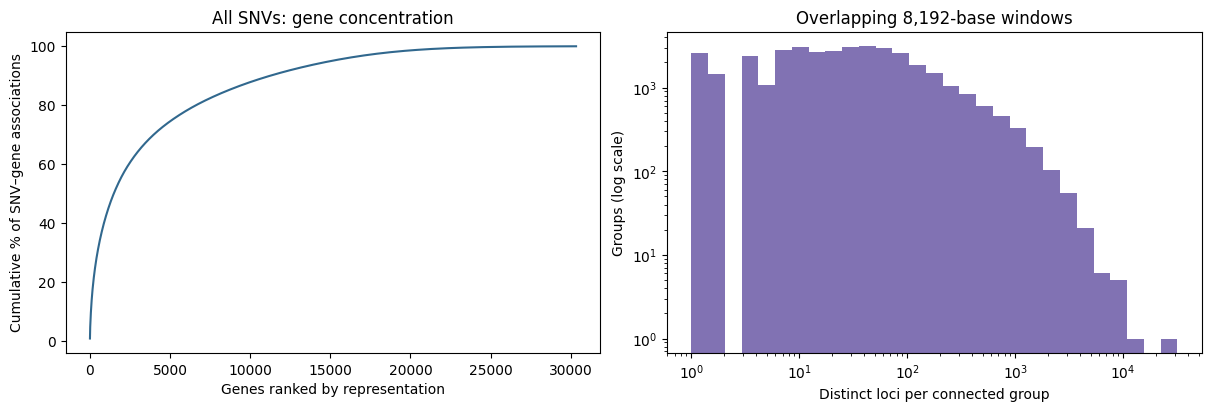

In [5]:
q0.show_grouping(variants)

## 6. Proposed cohort

Keep chromosomes 1–22/X/Y, single A/C/G/T substitutions, one of the six accepted germline labels, **≥2 review stars**, no germline conflict evidence, and at least one positive NCBI Gene ID. Preserve all gene associations. Exclude inconsistent duplicate keys before other filters; collapse consistent keys and retain their source IDs.

This deliberately narrows coverage; it does not select a representative clinical population. The review threshold and exclusions are explicit research choices, not validated performance improvements.

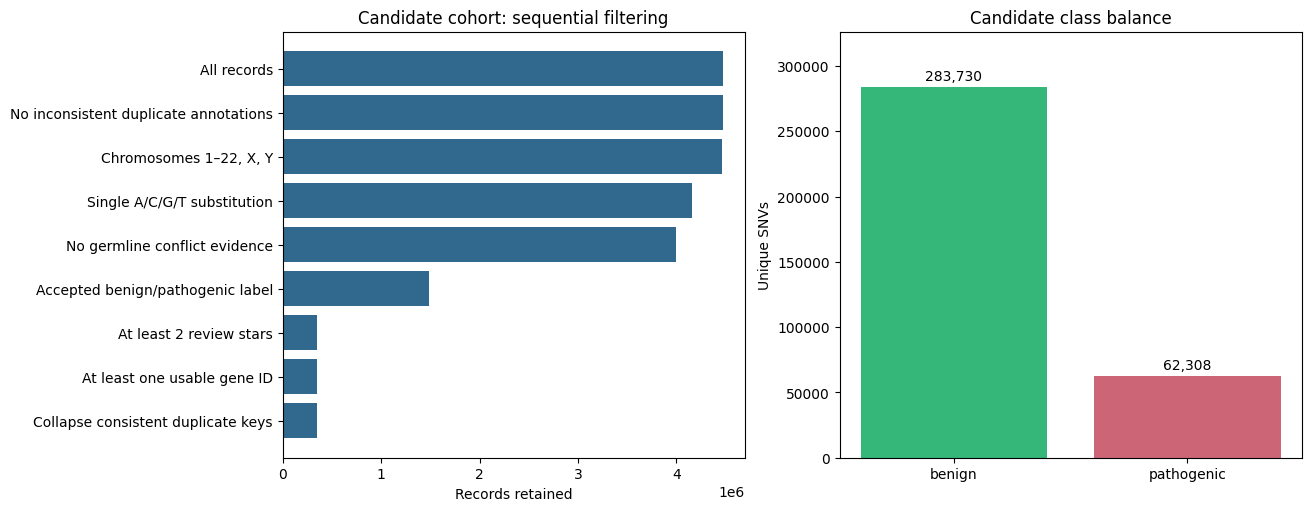

,stage,retained,removed
0,All records,4469028,0
1,No inconsistent duplicate annotations,4469028,0
2,"Chromosomes 1–22, X, Y",4465847,3181
3,Single A/C/G/T substitution,4157786,308061
4,No germline conflict evidence,3998278,159508
5,Accepted benign/pathogenic label,1486095,2512183
6,At least 2 review stars,346039,1140056
7,At least one usable gene ID,346038,1
8,Collapse consistent duplicate keys,346038,0


,chrom,pos,ref,alt,CLNSIG,CLNREVSTAT,gene_ids
68,1,930204,G,A,Benign,"criteria_provided,_multiple_submitters,_no_conflicts",148398
84,1,930248,G,A,Likely_benign,"criteria_provided,_multiple_submitters,_no_conflicts",148398
99,1,930282,G,A,Likely_benign,"criteria_provided,_multiple_submitters,_no_conflicts",148398
107,1,930314,C,T,Benign,"criteria_provided,_multiple_submitters,_no_conflicts",148398
138,1,931042,C,T,Benign,"criteria_provided,_multiple_submitters,_no_conflicts",148398
169,1,935779,G,A,Benign/Likely_benign,"criteria_provided,_multiple_submitters,_no_conflicts",148398
190,1,935835,C,G,Benign,"criteria_provided,_multiple_submitters,_no_conflicts",148398
201,1,935849,G,C,Likely_benign,"criteria_provided,_multiple_submitters,_no_conflicts",148398
207,1,935859,C,T,Benign,"criteria_provided,_multiple_submitters,_no_conflicts",148398
225,1,935907,C,T,Likely_benign,"criteria_provided,_multiple_submitters,_no_conflicts",148398


In [6]:
cohort, funnel = q0.show_cohort(variants, audit)

In [7]:
summary = q0.save_results(variants, cohort, funnel, audit, provenance, started)

Exported 346,038 proposed variants across 13,509 gene IDs to /root/gamow/notebooks/results/q0
Completed in 2.0 minutes (CPU).


**Finding for this pinned input:** the rules retain **346,038 SNVs (7.7%)** across **13,509 gene IDs**; **82.0%** are benign. No repeated variant keys were found, but 436,169 loci have multiple alternate alleles. A strict grouping strategy is still needed before model evaluation.

**Outputs:** [summary](results/q0/summary.json), [filter counts](results/q0/filter_counts.csv), [proposed cohort](results/q0/cohort.csv.gz), and [environment](results/q0/environment.json). These local artifacts are regenerated by this notebook and excluded from Git.

The cohort manifest contains labels and label-derived audit metadata; it must not be used wholesale as model input. No frozen split manifest exists yet. Before modeling, freeze groups and splits, verify sequence construction, and resolve or document circular annotations and pretraining contamination. Q0 has explored the complete input: it does not establish an untouched holdout.